In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numba

In [3]:
import matplotlib.pyplot as plt
import numba
from numba import cuda
import numpy as np
import time
import math

Image size: 3167 x 3167
Pixels count: 10029889


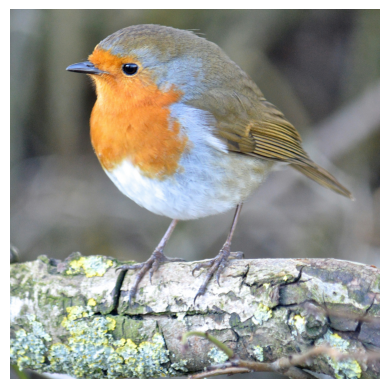

In [4]:
rgb_img = plt.imread('/content/drive/MyDrive/Dataset/HPC/bigger_bird.jpg')
h, w, _ = rgb_img.shape
pixelCount = h * w

print(f"Image size: {h} x {w}")
print(f"Pixels count: {pixelCount}")

plt.imshow(rgb_img)
plt.axis("off")
plt.show()

**RGB to HSV**

In [5]:
@cuda.jit
def rgb_to_hsv(r, g, b):
  r = r / 255.0
  g = g / 255.0
  b = b / 255.0

  max_rgb = max(r, max(g, b))
  min_rgb = min(r, min(g, b))
  delta = max_rgb - min_rgb

  if delta == 0:
    h = 0
  elif max_rgb == r:
    h = 60.0 * (((g - b) / delta) % 6)
  elif max_rgb == g:
    h = 60.0 * (((b - r) / delta) + 2)
  elif max_rgb == b:
    h = 60.0 * (((r - g) / delta) + 4)

  if max_rgb == 0:
    s = 0
  else:
    s = delta / max_rgb

  v = max_rgb

  return h, s, v

@cuda.jit
def hsv_to_rgb(h, s, v):
  d = h / 60
  hi = int(d % 6)
  f = d - hi

  l = v * (1 - s)
  m = v * (1 - f * s)
  n = v * (1 - (1 - f) * s)

  if 0 <= h <= 60:
    r = v
    g = n
    b = l
  elif 60 < h <= 120:
    r = m
    g = v
    b = l
  elif 120 < h <= 180:
    r = l
    g = v
    b = n
  elif 180 < h <= 240:
    r = l
    g = m
    b = v
  elif 240 < h <= 300:
    r = n
    g = l
    b = v
  elif 300 < h <= 360:
    r = v
    g = l
    b = m

  return int(r * 255.0), int(g * 255.0), int(b * 255.0)


RGB to H, S, V values kernel

In [6]:
@cuda.jit
def rgb2hsv_kernel(rgb, hue, sat, val):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  h, w, _ = rgb.shape

  if tidx < w and tidy < h:
    h, s, v = rgb_to_hsv(rgb[tidy, tidx, 0], rgb[tidy, tidx, 1], rgb[tidy, tidx, 2])
    hue[tidy, tidx] = h
    sat[tidy, tidx] = s
    val[tidy, tidx] = v

H, S, V to RGB kernel

In [7]:
@cuda.jit
def hsv2rgb_kernel(hue, sat, val, rgb):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  h, w = hue.shape
  if tidx < w and tidy < h:
    r, g, b = hsv_to_rgb(hue[tidy, tidx], sat[tidy, tidx], val[tidy, tidx])
    rgb[tidy, tidx, 0] = np.uint8(r)
    rgb[tidy, tidx, 1] = np.uint8(g)
    rgb[tidy, tidx, 2] = np.uint8(b)

In [8]:
def rgb2hsv_gpu(rgb, blockSize):
  h, w, _ = rgb.shape
  gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
  rgb_gpu = cuda.to_device(rgb)
  hue_gpu = cuda.device_array((h, w), dtype=np.float32)
  sat_gpu = cuda.device_array((h, w), dtype=np.float32)
  val_gpu = cuda.device_array((h, w), dtype=np.float32)

  rgb2hsv_kernel[gridSize, blockSize](rgb_gpu, hue_gpu, sat_gpu, val_gpu)

  return hue_gpu.copy_to_host(), sat_gpu.copy_to_host(), val_gpu.copy_to_host()

def hsv2rgb_gpu(hue, sat, val, blockSize):
  h, w = hue.shape
  gridSize = (math.ceil(w / blockSize[0]), math.ceil(h / blockSize[1]))
  hue_gpu = cuda.to_device(hue)
  sat_gpu = cuda.to_device(sat)
  val_gpu = cuda.to_device(val)
  rgb_gpu = cuda.device_array((h, w, 3), dtype=np.uint8)

  hsv2rgb_kernel[gridSize, blockSize](hue_gpu, sat_gpu, val_gpu, rgb_gpu)

  return rgb_gpu.copy_to_host()

In [11]:
def gpu_time_hsv(img, blockSize, n_runs):
  h, s, v = rgb2hsv_gpu(img, blockSize)

  time_rgb_to_hsv, time_hsv_to_rgb = [], []
  for i in range(n_runs):
    start = time.time()
    h, s, v = rgb2hsv_gpu(img, blockSize)
    end = time.time()
    time_rgb_to_hsv.append(end - start)

    start = time.time()
    rgb = hsv2rgb_gpu(h, s, v, blockSize)
    end = time.time()
    time_hsv_to_rgb.append(end - start)
    print(f"Run {i+1:2d}: RGB2HSV {time_rgb_to_hsv[-1]:.4f}s | HSV2RGB {time_hsv_to_rgb[-1]:.4f}s")

  print(f"\nGPU RGB2HSV with 2D block size = {blockSize}: {np.mean(time_rgb_to_hsv):.4f}s ± {np.std(time_hsv_to_rgb):.4f}s (mean of {n_runs} runs)")
  print(f"GPU HSV2RGB with 2D block size = {blockSize}: {np.mean(time_rgb_to_hsv):.4f}s ± {np.std(time_hsv_to_rgb):.4f}s (mean of {n_runs} runs)")
  return h, s, v, rgb

Run  1: RGB2HSV 0.0969s | HSV2RGB 0.0550s
Run  2: RGB2HSV 0.0999s | HSV2RGB 0.0634s
Run  3: RGB2HSV 0.0833s | HSV2RGB 0.0646s
Run  4: RGB2HSV 0.0814s | HSV2RGB 0.0583s
Run  5: RGB2HSV 0.0839s | HSV2RGB 0.0484s
Run  6: RGB2HSV 0.0956s | HSV2RGB 0.0483s
Run  7: RGB2HSV 0.0792s | HSV2RGB 0.0603s
Run  8: RGB2HSV 0.0726s | HSV2RGB 0.0416s
Run  9: RGB2HSV 0.0795s | HSV2RGB 0.0459s
Run 10: RGB2HSV 0.0853s | HSV2RGB 0.0420s

GPU RGB2HSV with 2D block size = (32, 32): 0.0858s ± 0.0082s (mean of 10 runs)
GPU HSV2RGB with 2D block size = (32, 32): 0.0858s ± 0.0082s (mean of 10 runs)


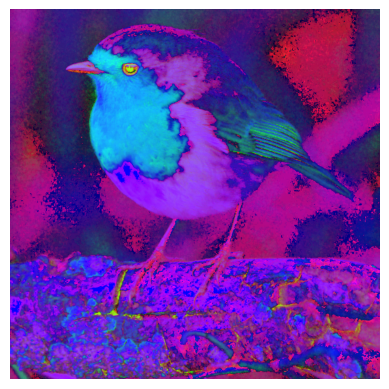

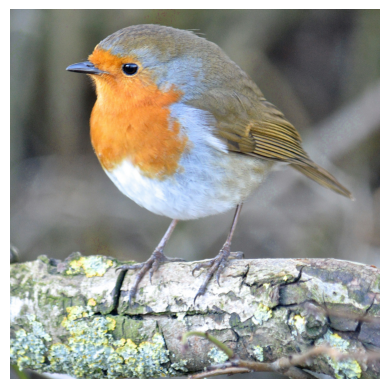

In [13]:
blockSize = (32, 32)
N_RUNS = 10

H, S, V, rgb_back = gpu_time_hsv(rgb_img, blockSize, N_RUNS)

hsv_img = np.dstack((H / 360.0, S, V))

plt.imshow(hsv_img)
plt.axis("off")
plt.savefig("hsv_gpu_2D.jpg", bbox_inches="tight", pad_inches=0)
plt.show()

plt.imshow(rgb_back)
plt.axis("off")
plt.savefig("rgb_from_hsv_gpu_2D.jpg", bbox_inches="tight", pad_inches=0)
plt.show()